In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import ttest_1samp
import matplotlib.colors as mcolors

In [2]:
# Import all the files
y2000 = xr.open_dataset("../LessOzone_Real_V1_atm_2d_ml_20000101T000000Z.nc")
y2001 = xr.open_dataset("../LessOzone_Real_V1_atm_2d_ml_20010101T000000Z.nc")
y2002 = xr.open_dataset("../LessOzone_Real_V1_atm_2d_ml_20020101T000000Z.nc")
y2003 = xr.open_dataset("../LessOzone_Real_V1_atm_2d_ml_20030101T000000Z.nc")
y2004 = xr.open_dataset("../LessOzone_Real_V1_atm_2d_ml_20040101T000000Z.nc")

In [3]:
# ATTENTION: Only run once!
# Changing the temporal dimension from float YYYYMMDD to string YYYY-MM-DD -> there are some difficulties otherwise

# 4x CO2 2D
date_floats = y2000["time"].values
date_strs = [str(int(d)) for d in date_floats]
date_iso = [f"{d[:4]}-{d[4:6]}-{d[6:]}" for d in date_strs]
date_dt = pd.to_datetime(date_iso)
y2000 = y2000.assign_coords(time=date_dt)

date_floats = y2001["time"].values
date_strs = [str(int(d)) for d in date_floats]
date_iso = [f"{d[:4]}-{d[4:6]}-{d[6:]}" for d in date_strs]
date_dt = pd.to_datetime(date_iso)
y2001 = y2001.assign_coords(time=date_dt)

date_floats = y2002["time"].values
date_strs = [str(int(d)) for d in date_floats]
date_iso = [f"{d[:4]}-{d[4:6]}-{d[6:]}" for d in date_strs]
date_dt = pd.to_datetime(date_iso)
y2002 = y2002.assign_coords(time=date_dt)

date_floats = y2003["time"].values
date_strs = [str(int(d)) for d in date_floats]
date_iso = [f"{d[:4]}-{d[4:6]}-{d[6:]}" for d in date_strs]
date_dt = pd.to_datetime(date_iso)
y2003 = y2003.assign_coords(time=date_dt)

date_floats = y2004["time"].values
date_strs = [str(int(d)) for d in date_floats]
date_iso = [f"{d[:4]}-{d[4:6]}-{d[6:]}" for d in date_strs]
date_dt = pd.to_datetime(date_iso)
y2004 = (y2004.assign_coords(time=date_dt))

In [4]:
y2d = xr.open_dataset("../LessOzone_2000-2005_2d.nc")
y3d = xr.open_dataset("../LessOzone_2000-2005_3d.nc")

In [5]:
date_floats = y2d["time"].values
date_strs = [str(int(d)) for d in date_floats]
date_iso = [f"{d[:4]}-{d[4:6]}-{d[6:]}" for d in date_strs]
date_dt = pd.to_datetime(date_iso)
y2d = (y2d.assign_coords(time=date_dt))

In [6]:
date_floats = y3d["time"].values
date_strs = [str(int(d)) for d in date_floats]
date_iso = [f"{d[:4]}-{d[4:6]}-{d[6:]}" for d in date_strs]
date_dt = pd.to_datetime(date_iso)
y3d = (y3d.assign_coords(time=date_dt))

In [7]:
y3d

<xarray.Dataset> Size: 3GB
Dimensions:      (ncells: 20480, vertices: 3, height: 47, bnds: 2, time: 60)
Coordinates:
  * height       (height) float64 376B 1.0 2.0 3.0 4.0 ... 44.0 45.0 46.0 47.0
  * time         (time) datetime64[ns] 480B 2000-02-01 2000-03-01 ... 2005-01-01
    clon         (ncells) float32 82kB ...
    clat         (ncells) float32 82kB ...
Dimensions without coordinates: ncells, vertices, bnds
Data variables: (12/16)
    clon_bnds    (ncells, vertices) float32 246kB ...
    clat_bnds    (ncells, vertices) float32 246kB ...
    height_bnds  (height, bnds) float64 752B ...
    zg           (height, ncells) float32 4MB ...
    ps           (time, ncells) float32 5MB ...
    pfull        (time, height, ncells) float32 231MB ...
    ...           ...
    wap          (time, height, ncells) float32 231MB ...
    hus          (time, height, ncells) float32 231MB ...
    clw          (time, height, ncells) float32 231MB ...
    cli          (time, height, ncells) float32 231MB ...
    hur          (time, height, ncells) float32 231MB ...
    cl           (time, height, ncells) float32 231MB ...
Attributes: (12/13)
    CDI:                  Climate Data Interface version 2.6.0 (https://mpime...
    Conventions:          CF-1.6
    number_of_grid_used:  13
    grid_file_uri:        http://icon-downloads.mpimet.mpg.de/grids/public/mp...
    uuidOfHGrid:          c8481318-398c-11e8-a225-05e6d8b4e7ef
    uuidOfVGrid:          0a1df915-12fb-d8bd-ed0c-cb104a832900
    ...                   ...
    institution:          Max Planck Institute for Meteorology/Deutscher Wett...
    title:                ICON simulation
    history:              Tue May 12 15:49:45 2026: cdo mergetime LessOzone_R...
    references:           see MPIM/DWD publications
    comment:              None ICON06 (icon06) on n4909-043 (Linux 4.18.0-477...
    CDO:                  Climate Data Operators version 2.6.0 (https://mpime...

In [8]:
data = y2d.rsus.sel(time="2000-02-01T00:00:00.000000000")

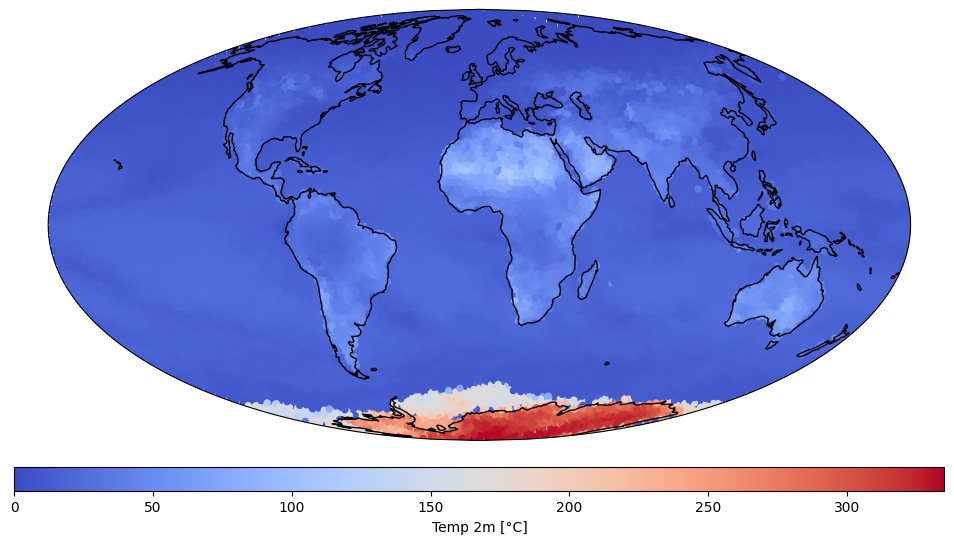

In [9]:
lon = np.rad2deg(data.clon.values)
lat = np.rad2deg(data.clat.values)
values = data.values

fig = plt.figure(figsize=(12,7))
ax = plt.axes(projection=ccrs.Mollweide())
ax.set_global()
ax.coastlines(resolution="110m", linewidth=1)

#norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=values.min(), vmax=values.max())

sc = ax.scatter(
    lon, lat,
    c=values,
    s=18,
    cmap="coolwarm",
    transform=ccrs.PlateCarree(),
    #norm=norm
)

#mask_bool = mask.values
"""
ax.scatter(
    #lon[mask_bool],
    #lat[mask_bool],
    facecolors="none",
    edgecolors="k",
    linewidths=0.1,
    c="black",
    s=2,
    transform=ccrs.PlateCarree()
)"""

plt.colorbar(
    sc, ax=ax, orientation='horizontal', pad=0.05, aspect=40,
    label="Temp 2m [°C]"
)

#ax.set_title(name)
#plt.savefig(savename + ".png", dpi=300, bbox_inches="tight")
#plt.show()

In [10]:
y2d

<xarray.Dataset> Size: 207MB
Dimensions:    (ncells: 20480, vertices: 3, time: 60)
Coordinates:
  * time       (time) datetime64[ns] 480B 2000-02-01 2000-03-01 ... 2005-01-01
    clon       (ncells) float32 82kB 1.274 1.274 1.243 ... 1.356 1.302 1.327
    clat       (ncells) float32 82kB 0.9182 0.9402 0.907 ... -0.8169 -0.7823
Dimensions without coordinates: ncells, vertices
Data variables: (12/45)
    clon_bnds  (ncells, vertices) float32 246kB ...
    clat_bnds  (ncells, vertices) float32 246kB ...
    orog       (ncells) float32 82kB ...
    ps         (time, ncells) float32 5MB ...
    psl        (time, ncells) float32 5MB ...
    cosmu0     (time, ncells) float32 5MB ...
    ...         ...
    sfcwind    (time, ncells) float32 5MB ...
    uas        (time, ncells) float32 5MB ...
    vas        (time, ncells) float32 5MB ...
    tas        (time, ncells) float32 5MB ...
    dew2       (time, ncells) float32 5MB ...
    ptp        (time, ncells) float32 5MB ...
Attributes:
    CDI:                  Climate Data Interface version 2.6.0 (https://mpime...
    Conventions:          CF-1.6
    number_of_grid_used:  13
    grid_file_uri:        http://icon-downloads.mpimet.mpg.de/grids/public/mp...
    uuidOfHGrid:          c8481318-398c-11e8-a225-05e6d8b4e7ef
    source:               Unknown@Unknown
    institution:          Max Planck Institute for Meteorology/Deutscher Wett...
    title:                ICON simulation
    history:              Tue May 12 15:26:08 2026: cdo mergetime LessOzone_R...
    references:           see MPIM/DWD publications
    comment:              None ICON06 (icon06) on n4909-043 (Linux 4.18.0-477...
    CDO:                  Climate Data Operators version 2.6.0 (https://mpime...

In [11]:
values = data.values

In [13]:
y2d

<xarray.Dataset> Size: 207MB
Dimensions:    (ncells: 20480, vertices: 3, time: 60)
Coordinates:
  * time       (time) datetime64[ns] 480B 2000-02-01 2000-03-01 ... 2005-01-01
    clon       (ncells) float32 82kB 1.274 1.274 1.243 ... 1.356 1.302 1.327
    clat       (ncells) float32 82kB 0.9182 0.9402 0.907 ... -0.8169 -0.7823
Dimensions without coordinates: ncells, vertices
Data variables: (12/45)
    clon_bnds  (ncells, vertices) float32 246kB ...
    clat_bnds  (ncells, vertices) float32 246kB ...
    orog       (ncells) float32 82kB ...
    ps         (time, ncells) float32 5MB ...
    psl        (time, ncells) float32 5MB ...
    cosmu0     (time, ncells) float32 5MB ...
    ...         ...
    sfcwind    (time, ncells) float32 5MB ...
    uas        (time, ncells) float32 5MB ...
    vas        (time, ncells) float32 5MB ...
    tas        (time, ncells) float32 5MB ...
    dew2       (time, ncells) float32 5MB ...
    ptp        (time, ncells) float32 5MB ...
Attributes:
    CDI:                  Climate Data Interface version 2.6.0 (https://mpime...
    Conventions:          CF-1.6
    number_of_grid_used:  13
    grid_file_uri:        http://icon-downloads.mpimet.mpg.de/grids/public/mp...
    uuidOfHGrid:          c8481318-398c-11e8-a225-05e6d8b4e7ef
    source:               Unknown@Unknown
    institution:          Max Planck Institute for Meteorology/Deutscher Wett...
    title:                ICON simulation
    history:              Tue May 12 15:26:08 2026: cdo mergetime LessOzone_R...
    references:           see MPIM/DWD publications
    comment:              None ICON06 (icon06) on n4909-043 (Linux 4.18.0-477...
    CDO:                  Climate Data Operators version 2.6.0 (https://mpime...